# Unsupervised Learning: Clustering Lab





In [47]:
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.metrics import silhouette_score
import numpy as np
import pandas as pd
from scipy.io import arff

## 1. Initial practice with the K-means and HAC algorithms

### 1.1 (10%) K-means
Run K-means on this [Abalone Dataset.](https://raw.githubusercontent.com/cs472ta/CS472/master/datasets/abalone.arff)
The dataset was modified to be smaller. The last datapoint should be on line 359 or the point 0.585,0.46,0.185,0.922,0.3635,0.213,0.285,10. The remaining points are commented out. Treat the output class (last column) as an additional input feature. Create your K-Mmeans model with the paramaters K-means(n_clusters=3, init='random', n_init=1) 

Output the following:
- Class label for each point (labels_)
- The k=3 cluster centers (cluster_centers_)
- Number of iterations it took to converge (n_iter_)
- Total sum squared error of each point from its cluster center (inertia_)
- The total average silhouette score (see sklearn.metrics silhouette_score)

In [48]:
# K-means with Abalone
train_data,_ = arff.loadarff("data/abalone.arff")

abalone_df = pd.DataFrame(train_data)

# Quick EDA
print("First 5 rows of glass data set:")
display(abalone_df.head())

print("\nAbalone Feature Distribution:")
display(abalone_df.value_counts().sort_index()) # here we see lots of unique data

print(f"Data shape: {abalone_df.shape}")

# no train test split since this is all exploratory
# create the model

clusters = 3

kmeans_abalone = KMeans(n_clusters = clusters, init = "random", n_init = 1)
kmeans_abalone.fit(abalone_df)

labels = kmeans_abalone.labels_
centers = kmeans_abalone.cluster_centers_
n_iterations = kmeans_abalone.n_iter_
total_sse = kmeans_abalone.inertia_

# reshape data so silhouette score can be calculated
reshaped_train_data = train_data.view(np.float64).reshape(train_data.shape[0], -1)
avg_silhouette = silhouette_score(reshaped_train_data, labels)

# format and display all metrics
metrics = {
    "Metric": ["Number of Iterations", "Total SSE (Inertia)", "Avg Silhouette Score"],
    "Value":  [n_iterations, round(total_sse, 4), round(avg_silhouette, 4)]
}
print(f"\nKMeans Model Metrics (Abalone) with n_clusters = {clusters}:")
display(pd.DataFrame(metrics))

# cluster centers in their own table
centers_df = pd.DataFrame(
    centers,
    columns=abalone_df.columns,
    index=[f"Cluster {i}" for i in range(len(centers))]
)
print("\nCluster Centers:")
display(centers_df)

# labels as a compact series
print("\nPoint Labels:")
labels_df = pd.DataFrame({"Point": range(len(labels)), "Cluster Label": labels})
display(labels_df)

First 5 rows of glass data set:


,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
0,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15.0
1,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7.0
2,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9.0
3,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10.0
4,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7.0



Abalone Feature Distribution:


Length  Diameter  Height  Whole_weight  Shucked_weight  Viscera_weight  Shell_weight  Rings
0.170   0.130     0.095   0.0300        0.0130          0.0080          0.0100        4.0      1
0.175   0.130     0.055   0.0315        0.0105          0.0065          0.0125        5.0      1
0.205   0.150     0.055   0.0420        0.0255          0.0150          0.0120        5.0      1
0.210   0.150     0.050   0.0420        0.0175          0.0125          0.0150        4.0      1
0.225   0.160     0.045   0.0465        0.0250          0.0150          0.0150        4.0      1
                                                                                              ..
0.705   0.560     0.220   1.9810        0.8175          0.3085          0.7600        14.0     1
0.710   0.540     0.165   1.9590        0.7665          0.2610          0.7800        18.0     1
0.725   0.560     0.210   2.1410        0.6500          0.3980          1.0050        18.0     1
        0.570     0.190   2.5500   

Data shape: (200, 8)

KMeans Model Metrics (Abalone) with n_clusters = 3:


,Metric,Value
0,Number of Iterations,2.0000
1,Total SSE (Inertia),540.2110
2,Avg Silhouette Score,0.5011



Cluster Centers:


,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
Cluster 0,0.581228,0.456491,0.160439,1.055237,0.410456,0.231000,0.339868,12.333333
Cluster 1,0.442212,0.343982,0.113319,0.497628,0.206783,0.114310,0.155345,8.247788
Cluster 2,0.613667,0.489333,0.167167,1.292833,0.488150,0.258733,0.454883,17.066667



Point Labels:


,Point,Cluster Label
0,0,2
1,1,1
2,2,1
3,3,1
4,4,1
...,...,...
195,195,0
196,196,0
197,197,2
198,198,2


#### Discussion
Discuss your results. Run it a few times. What happens? How did the cluster silhouette scores compare? <br>
Now play around with k. What happens to the clusters and silhouette scores?

Discussion of Code:
    Here, following the typical workflow, I load the data, make and fit the model. And then grab all of the requested metrics using scikit learns built in functions and the models attributes. These are then all displayed in nice little tables for a certain value of k.

Discussion of Results: 
    For n_clusters = 3, the initial run, the silhouette score was 0.5184. Though I didn't directly display it, I ran the same model, but with a different n_cluster value. The silhouette score changed as stated below for each of the different values of k.

n_clusters = 5: 0.5095
n_clusters = 7: 0.4751
n_clusters = 9: 0.5091
n_clusters = 11: 0.5025

As I understand it, a silhouette score is essentially just a measure of how well each point fits into it's assigned cluster. Values can range from -1 (does not fit well) to 1 (fits very well). Here, we see a very consistent score around 0.5 - not bad, but also still room for improvement. I think this would suggest that there is no super clear "winner" for values of k with this data, or, at least, with the other hyperparameters that are being used to train this model. There is also a chance that, since KMeans assumes roughly circular/spherical clusters, that there are other methods that would be better at finding patterns/clusters/groups in this data than KMeans. 

It is also important to note that there was no distinct differences in what was shown in the cluster table as the value of k increased. It simply showed that, as k increased, there were more groups created, but not that anything necessarily was being grouped in a better way. It seems that this data just shows a clear correlation between age and size, which makes sense, and that there is no other underlying pattern. This is a great explanation for why the silhouette scores stay about the same no matter the value of k. This data simply just has one continuous gradient rather than clear groups.

### 1.2 (10%) Hierarchical Agglomerative Clustering (HAC) 

Run HAC on the same [Abalone Dataset](https://raw.githubusercontent.com/cs472ta/CS472/master/datasets/abalone.arff) using complete linkage and k=3.

Output the following:
- Class label for each point (labels_)
- The total average silhouette score

In [49]:
# HAC with Abalone
# See cells above for a EDA on this data set.

# Reload data because I think I messed with it too much in the section above
train_data,_ = arff.loadarff("data/abalone.arff")
abalone_df = pd.DataFrame(train_data)

# initialize and fit the model
hac = AgglomerativeClustering(n_clusters = 3, linkage = "complete")
hac.fit(abalone_df)

# get the metrics needed
labels = hac.labels_
avg_silhouette = silhouette_score(abalone_df, labels)

metrics = {
    "Metric": "Avg Silhouette Score",
    "Value":  round(avg_silhouette, 4)
}
print(f"\nAgglomerative Clustering (Abalone) Silhouette Score:")
display(pd.DataFrame([metrics]))

# labels as a compact series
print("\nPoint Labels for Agglomerative Clustering:")
labels_df = pd.DataFrame({"Point": range(len(labels)), "Cluster Label": labels})
display(labels_df)

# manually compute the centers so that we can compare with them
hac_centers = np.array([
    abalone_df[labels == i].mean(axis=0) 
    for i in range(3)
])

centers_df = pd.DataFrame(
    hac_centers,
    columns=abalone_df.columns,
    index=[f"Cluster {i}" for i in range(3)]
)
display(centers_df)



Agglomerative Clustering (Abalone) Silhouette Score:


,Metric,Value
0,Avg Silhouette Score,0.5398



Point Labels for Agglomerative Clustering:


,Point,Cluster Label
0,0,1
1,1,0
2,2,0
3,3,0
4,4,0
...,...,...
195,195,1
196,196,0
197,197,1
198,198,1


,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
Cluster 0,0.444412,0.345714,0.113950,0.500508,0.207987,0.114500,0.156630,8.386555
Cluster 1,0.591691,0.467353,0.164412,1.114868,0.432581,0.241000,0.362779,13.220588
Cluster 2,0.645385,0.511538,0.171154,1.522615,0.557000,0.294808,0.558846,19.230769


#### Discussion
How do the clusters compare to your results above? Explain the differences using what you know about HAC.

Discussion of Code:
    I reloaded the dataset here because I was having some issues with fitting the model. Reloding the data set seemed to work just fine so I just went with that. From there, I initialized and trained the model as the instructions perscribed. I then, similar to the last problem, got the disired metrics from my model with the built in scikit learn functions and the attributes of the AgglomerativeClustering model. I also, because the HAC does not have a cluster centers attributes (because that is not how the model works) took it upon myself to calculate the cluster centers so that I could compare it more fairly to the KMeans algorithm with this same data set.

Dicussion of Results:
    It is important to note firstly that the Silhouette score of this model is slightly higher than any of the iterations of the KMeans models that were attempted in the prior step. Not by a lot, but it is worth noting. 

In addition to that, there is some important information to be drawn from comparing the cluster centers from both algorithms. The KMeans clustering algorithm is built around centers - the algorithm first picks random centers, and then corrects as it goes. It is trying to find the most mathematically convientient explantion/groupings of the data based on it's assumptions that there will be naturally existing circular clusters. Because it randomly assigns some points in the data as the centers, it will always have some slight variation in the output of grouping. HAC does not do this - instead, it is a deterministic algorithm that kind of builds from the bottom up. It is way more data-driven of an algorithm because it makes no such circular assumptions. This is seen in the cluster center outputs, they drew different lines along this age line, espcially in the older and middle groups. 

In this case, it seems to be a better algorithm seeing as how the silhouette score (if we remember, a metric of how well the individual poitns are fitting in their assigned cluster as compared to the other existing groups) is higher on average. Meaning that it does a better job at assigning groups than the KMeans algorithm.

## 2. K-means Clustering with the [Iris Dataset](https://raw.githubusercontent.com/cs472ta/CS472/master/datasets/iris.arff)
Use the Iris data set for 2.1 and 2.2.  Don't include the output label as one of the input features.

### 2.1 (20%) K-means Initial Centroids Experiments
K-means results differ based on the initial centroids used.
- Run K-means 5 times with *k*=4, each time with different initial random centroids (init="random) and with n_init=1.  Give inertia and silhouette scores for each run and discuss any variations in the results.
- SKlearn has a parameter that does this automatically (n_init).  n_init = z runs K-means z times, each with different random centroids and returns the clustering with the best SSE (intertia) of the z runs. Try it out and discuss how it does and how it compares with your 5 runs above.
- Sklearn also has a parameter (init:'K-means++') which runs a simpler fast version of K-means first on the data to come up with good initial centroids, and then runs regular K-means with this centroids.  Try it out (with n_init = 1) and discuss.

In [50]:
# K-means initial centroid experiments

# Load the iris data set
train_data, _ = arff.loadarff("data/iris.arff")
iris_df = pd.DataFrame(train_data)

# drop the class from the training data
X = iris_df.drop(["class"], axis=1)

# 1. 
# manual runs 

# lists for my data frame later
inertias = []
sil_scores = []

# initialize my models and get their metrics
for _ in range(1, 6):
    kmeans = KMeans(n_clusters=4, init="random", n_init=1)
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X, kmeans.labels_))

runs = {
    "Run": range(1, 6),
    "Inertia": inertias,
    "Silhouette Score": sil_scores
}
runs = pd.DataFrame(runs)
print("\nManual Runs (random init, n_init=1)")
display(runs)

print("\nAverage Inertia and Silhouette Scores for manual runs:")
averages = {
    "Average Inertia": sum(inertias)/len(inertias),
    "Average Silhouette Score": sum(inertias)/len(inertias)
}
averages = pd.DataFrame([averages])
display(averages)

# 2. 
# n_init
kmeans_ninit = KMeans(n_clusters=4, init="random", n_init=5)
kmeans_ninit.fit(X)

# data tableee
sil_score = silhouette_score(X, kmeans_ninit.labels_)
ninit_metrics = {
    "Inertia": [kmeans_ninit.inertia_],
    "Silhouette Score": [sil_score]
}
ninit_metrics = pd.DataFrame(ninit_metrics)
print("\nn_init=5 (best of 5 automatic runs)")
display(ninit_metrics)

# 3. 
# KMeans++ with n_init=1
kmeans_pp = KMeans(n_clusters=4, init="k-means++", n_init=1)
kmeans_pp.fit(X)

sil_score = silhouette_score(X, kmeans_pp.labels_)
pp_metrics = {
    "Inertia": [kmeans_pp.inertia_],
    "Silhouette Score": [sil_score]
}
pp_metrics = pd.DataFrame(pp_metrics)
print("\nK-Means++ (n_init=1)")
display(pp_metrics)


Manual Runs (random init, n_init=1)


,Run,Inertia,Silhouette Score
0,1,71.348224,0.415405
1,2,57.473273,0.495120
2,3,71.340447,0.417105
3,4,71.348224,0.415405
4,5,71.348224,0.415405



Average Inertia and Silhouette Scores for manual runs:


,Average Inertia,Average Silhouette Score
0,68.571678,68.571678



n_init=5 (best of 5 automatic runs)


,Inertia,Silhouette Score
0,57.317873,0.497826



K-Means++ (n_init=1)


,Inertia,Silhouette Score
0,57.473273,0.49512


#### Discussion
Discuss your results. How does n_init work and compare with your first results without using n_init. <br>
How does K-means++ work? Compare it to your previous runs.

Discussion of Code:
    Per the usual, I started by loading my data set and doing a little quick EDA. Since we have used this data set before in this class, it was relatively easy to get through. I made sure to drop class from the training data, as specified. From there, I just ran a for loop, initializing a new model each time, and grabbed the metrics that were requested, adding them to a dictionary so I can display them as I have been doing. After that, I initialized, fit the model with n_init = 5, and also initialized and ran the model with inti = "k-means++" as requested. All results were formatted and printed, including an average table for the 5 runs that I ran so I could better see the average/general results that came form my manual runs.

Discussion of Results:
    Just to review, the silhouette score is a measure of how well the points fit in the groups that were decided by the model (values range from -1 to 1, where values closer to one indicate better groups). Inertia is essentially a measure of how tight / precise the groups are (where lower inertia means better, more compact groups).

With that in mind. The manual 5 runs have an interesting thing going on, where the first run has significantly worse inertia and silhouette scores than the other four runs. In fact, the other four runs actually all have identical scores for inertia and silhouette scores, perhaps indicating that there is a clear best solution to this data set that many different random models are able to converge to. Rather than use the average in this case, we will use the values that were obtained in runs 2-5 of the manual runs to compare. Interestingly, for the other two methods, they achieved scores that were nearly identical to runs 2-5 of the manual runs, just in different ways. 

Using a random model with n_init = 1 is not a good method of doing this, seeing as how there are a lot of things that can go wrong / you can just get an unlucky run. Using an n_init of greater than one tries to kind of brute-force this problem by just doing it many times and getting the best results from there. Which works, but is definitely still not the best answer. Here, using a different init method, in this case we used kmeans++, there is a much more elegant and efficient solution, because it does a random run first, finding the best centers this way, then runs the model again using these centers, offering a much smarter way to tackle this problem.


### 2.2 (20%) Silhouette Graphs
In this part you will show silhouette graphs for different *k* values.  Install the [Yellowbrick visualization package](https://www.scikit-yb.org/en/latest/quickstart.html) and import the [Silhouette Visualizer](https://www.scikit-yb.org/en/latest/api/cluster/silhouette.html).  This library includes lots of visualization packages which you might find useful. (Note: The YellowBrick silhouette visualizer does not currently support HAC).
- Show Silhouette graphs for clusterings with *k* = 2-6. Print the SSE (inertia) and total silhouette score for each.
- Learn with the default n_init = 10 to help insure a decent clustering.
- Using the silhouette graphs, choose which *k* you think is best and discuss why. Think about and discuss more than just the total silhouette score.

k=2
SSE (Inertia): 152.37
Silhouette Score: 0.6808


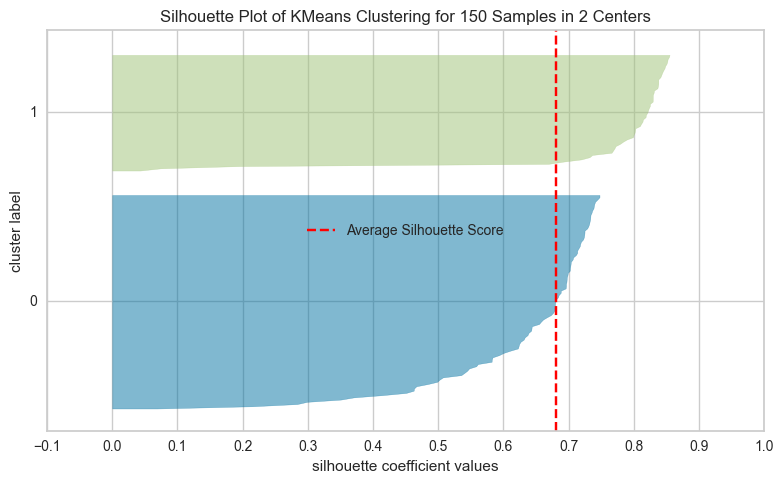

k=3
SSE (Inertia): 78.94
Silhouette Score: 0.5526


<Figure size 800x550 with 0 Axes>

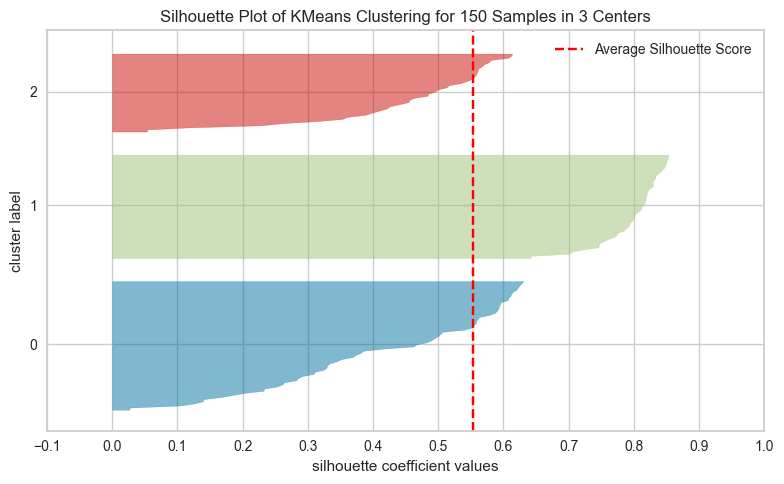

k=4
SSE (Inertia): 57.32
Silhouette Score: 0.4978


<Figure size 800x550 with 0 Axes>

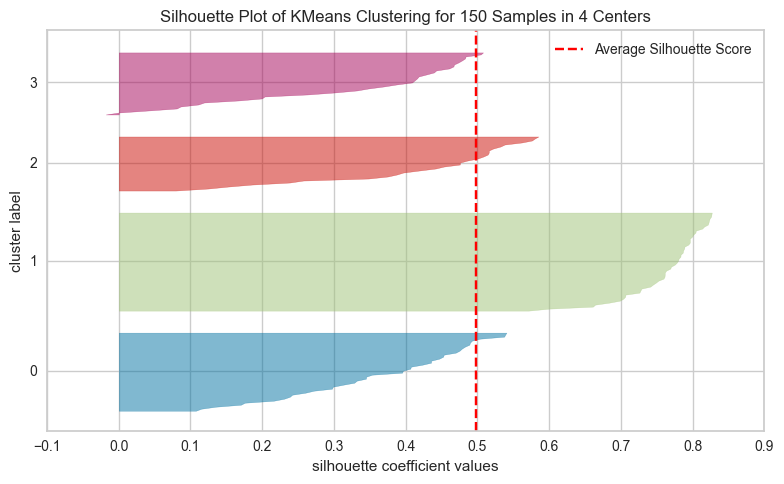

k=5
SSE (Inertia): 46.54
Silhouette Score: 0.4885


<Figure size 800x550 with 0 Axes>

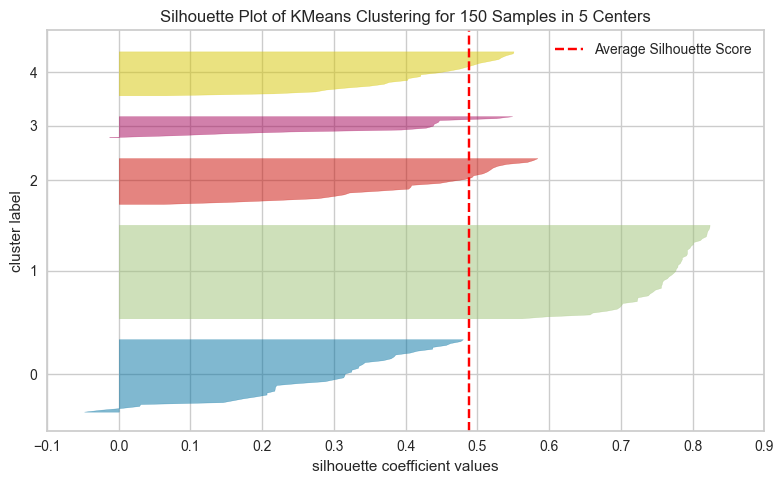

k=6
SSE (Inertia): 38.93
Silhouette Score: 0.3682


<Figure size 800x550 with 0 Axes>

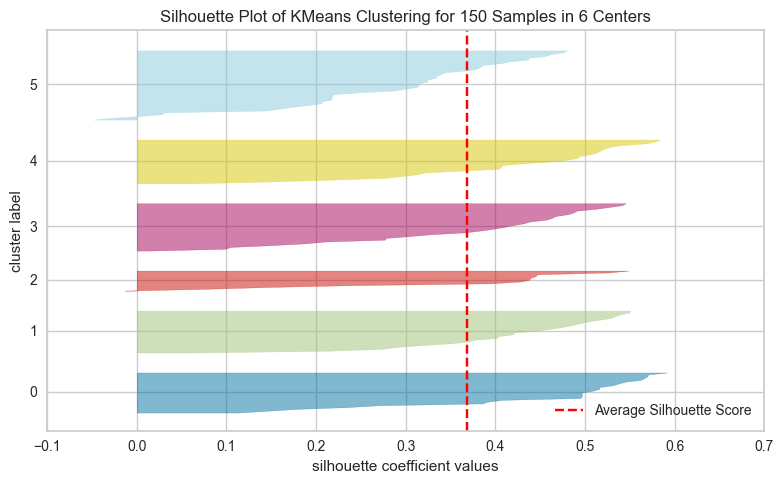

<Figure size 800x550 with 0 Axes>

In [51]:
# Iris Clustering with K-means and silhouette graphs
import sys
import setuptools._distutils as distutils
sys.modules["distutils"] = distutils
# I had to add these random import statements above because I couldn't get yellowbrick to work
# even after downgrading the version of python that I am using
from yellowbrick.cluster import SilhouetteVisualizer
import matplotlib.pyplot as plt

# to see an EDA, see previous cells
for k in range(2, 7):
    fig, ax = plt.subplots(figsize=(8, 5))
    
    # initialize KMeans model
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    
    # Create and fit the SilhouetteVisualizer
    visualizer = SilhouetteVisualizer(kmeans, colors='yellowbrick', ax=ax, force_model = True)
    visualizer.fit(X)
    
    # Print SSE (inertia) and silhouette score
    print(f"k={k}")
    print(f"SSE (Inertia): {kmeans.inertia_:.2f}")
    print(f"Silhouette Score: {visualizer.silhouette_score_:.4f}")
    
    visualizer.finalize()
    plt.tight_layout()
    plt.show()
    plt.clf()

#### Discussion
Discuss your results and justify which clustering is best based on the silhouette graphs

Discussion of Code:
    Not going to lie, this, even though the code was incredibly short and easy, was one of the most frusterating things I have done in this class so far haha. There were a lot of things that kept going wrong when I was attempting to get yellowbrick to work on my device, eventually I got it! Which is good for sure. From there, I did the typical, just set up a for loop from 2-7 so that I could report which values were which and be able to analyze the graphs. I made a kmeans estimator with the n_cluster that we were on. I did a little researach about the hyperparamters too, I was having an issue with the models not liking kmeans and so I had to force the model. It was a whole thing. Anyway, I was able to get all the plots to display just fine!

Discussion of Results:
    I am always suprised by what I see here. I would have guessed, and honestly been pretty sure about the fact that, the models with a higher, or maybe medium number of clusters were the ones that performed the best. That, it appears is not the case.

Looking into how these plots actually look / display the data, there are a couple things that you look for to be able to tell if the model does a good job. Those are:
    - higher average score (which is a red line on these graphs)
    - no negative values to be delt with
    - roughly balanced clusters
    - a gradual taper (as ones with sharp drop-offs can indicate lots of stragglers in the group)
    - a meaningful inertia score

With that in mind, lets look at the plots!

Plot 1 - k = 2:
    Here, we see a high average, two distinct clusters that have relatively equal size balance, no negative values, a gradual descent, and HIGH intertia and silhouette scores (152 and 0.68 respectively). By all accounts this seems to be the golden standard as far as these visualization plots go.

Plots 2-5:
    Interestingly, all of the criteria kind of get worse from here. As k increases, the average score, silhouette scores, and inertia all  decrease, sometimes with rather big drops. With k = 4,5,6 we see some negative values, indicating that there are some misclustered points (eek!!). With k = 3,4,5 we see very unbalanced cluster sizes, with k=5 especially having a huge outlier. As k increases, the gradient that we see in the plot of k = 2 dissapears, and the points are extremely jagged and rough. Overall, by all of the metrics, and very opposite to k = 2, there is a lot of unchecked boxes as far as what makes a good model.

Suprising but definitely very interesting and informative!!

## 3 (20%) Iris Clustering with HAC

- Use the same dataset as above and learn with HAC clustering
- Create one table with silhouette scores for k=2-6 for each of the linkage options single, average, complete, and ward

In [52]:
#HAC with Iris
# again, for eda information, please look at the cells above :) I don't want to be redundant.

# all of the linkage things to be used here in a second
linkages = ["single", "average", "complete", "ward"]

# results list
results = []

# for loop to get everything set up
for linkage in linkages:
    for k in range(2, 7):
        # initialize the model
        hac = AgglomerativeClustering(n_clusters = k, linkage = linkage)
        hac.fit(X)

        # labels, sihlouette scores, and appending to results
        labels = hac.labels_
        sil_score = silhouette_score(X, labels)
        results.append({"Linkage": linkage, "n_clusters": k, "Silhouette Score":round(sil_score, 4)})

results = pd.DataFrame(results)

print("Silhouette Scores for a given model with varying k and linkage:")
display(results)

Silhouette Scores for a given model with varying k and linkage:


,Linkage,n_clusters,Silhouette Score
0,single,2,0.6864
1,single,3,0.5118
2,single,4,0.2818
3,single,5,0.2835
4,single,6,0.2211
5,average,2,0.6864
6,average,3,0.5539
7,average,4,0.4717
8,average,5,0.4303
9,average,6,0.3407


#### Discussion
Discuss your results and compare with your k-means results. <br>
Discuss your table that contains the silhouette scores for k=2,3,4,5,6 and for each of the different linkage options. <br>
Discuss how the linkage options affect your scores.

Discussion of Code:
    Again, I skipped out on the EDA because we have been using the same data set for all of these parts and I though that it would be unecessary to do it more times. From there, I made a list of the different linkages that we would be using, and set up a double for loop where we could try each linkage method with each of the k values. I also made a list that I could append mini dictionaries to in order to have the results in a convienient formatting that I could just display at the end. If this class has taught me anything (other than all the machine learning concepts) it has taught me that I absolutely love pandas and it is such an amazing tool in python haha. It has made me life significantly easier and my results and outputs significantly better formatted.

Discussion of Results:
    Just for a little bit of context, I am going to leave my kmeans reults from the previous section here so they can be easily referred back to.

k=2 SSE (Inertia): 152.37 Silhouette Score: 0.6808 
k=3 SSE (Inertia): 78.94 Silhouette Score: 0.5526
k=4 SSE (Inertia): 57.32 Silhouette Score: 0.4978
k=5 SSE (Inertia): 46.54 Silhouette Score: 0.4885
k=6 SSE (Inertia): 38.93 Silhouette Score: 0.3682

What is interesting, and definitely something that I wasn't expecting to see, is that my results from HAC and KMeans are relatively consistent across the number of clusters that are being used for each model. k = 2 has the best scores across the board, no matter the linkage method or the algorithm that was used. Similarly, we see that as k increases, just like with kmeans, that the silhouette scores of the models decrease! I am guessing that the consistency that is shown across models and methods is suggestive that there is some true underlying patterns/groups present in the data that are able to be identified, regardless of model or method or algorithm.

In terms of the results that we optained with the HAC algorithm,we already discussed the pattern that exists as k increases in the secion above. That leaves talking about the effect of the different linkage options. Complete seems to be completely failing at k = 2, with the other linkage methods performing about the same. After that, single completely falls of the end - it seems to be consistenttly perform the worst out of all of the linkage options. For this particular dataset, it seems tha ward and average are the most consistend and best performers since they experience only a slow decrease in score rather than sharp drops like the other kinds do.

I would say that for clustering models, or at least the ones that we are doing, that going above k = 3 would not be a good choice, as scores just pretty sharply fall off from there.




## 4 (20%) Run both algorithms on a real world data
- Choose any real world data set which you have not used previously
- Use parameters of your choosing
- Try each algorithm a few times with different parameters and output one typical example of labels and silhouette scores for each algorithm
- Show the silhouette graph for at least one reasonable *k* value for K-means

Quick EDA:

First 5 rows of the Wine Quality dataset:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5



Wine Quality Distribution:


quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


KMeans Results:


,n_clusters:,Inertia:,Silhouette Scores
0,2,14330.119811,0.213730
1,3,12629.974592,0.189204
2,4,11459.143676,0.171636



HAC Results:


,n_clusters:,Linkage:,Silhouette Scores
0,2,ward,0.183402
1,3,ward,0.157747
2,3,average,0.563167


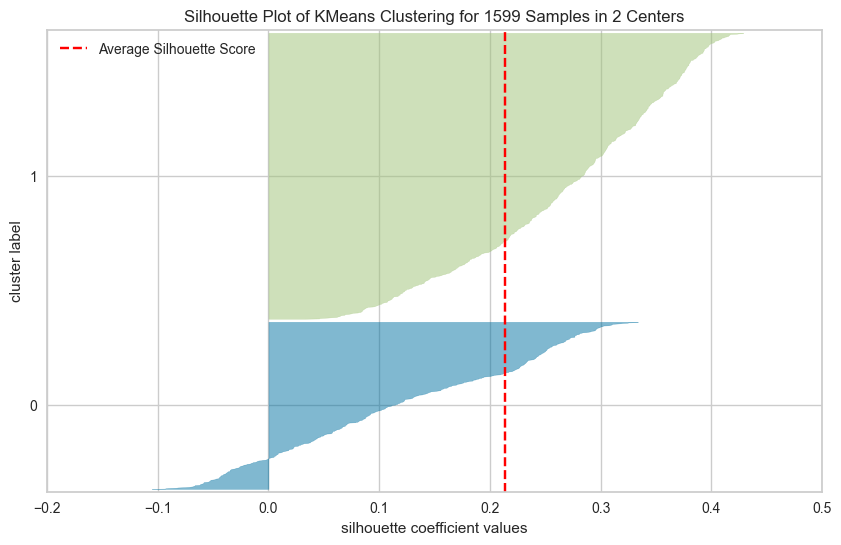

In [61]:
from sklearn.preprocessing import StandardScaler
# Run both algoriths on a data set of your choice

# Load the data
wine_df = pd.read_csv("data/winequality-white.csv", sep=';')

# Quick EDA
print("Quick EDA:")
print("\nFirst 5 rows of the Wine Quality dataset:")
display(wine_df.head())

print("\nWine Quality Distribution:")
display(wine_df["quality"].value_counts().sort_index())

# X, decided to drop the quality part
X = wine_df.drop(["quality"], axis = 1)

# scale the dataset so clustering can work the way it is supposed to
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# do kmeans first
print("\nKMeans Results:")

km1 = KMeans(n_clusters=2, n_init=10, random_state=42)
km2 = KMeans(n_clusters=3, n_init=10, random_state=42)
km3 = KMeans(n_clusters=4, n_init=10, random_state=42)

km_results = []

for km in [km1, km2, km3]:
    # fit
    km.fit(X_scaled)

    # get metrics
    labels = km.labels_
    sil_score  = silhouette_score(X_scaled, labels)
    inertia = km.inertia_

    # add to results list
    km_results.append({"n_clusters:" : km.n_clusters, "Inertia:": inertia, "Silhouette Scores": sil_score})

km_results = pd.DataFrame(km_results)
display(km_results)

# then hac
print("\nHAC Results:")

hac1 = AgglomerativeClustering(n_clusters=2, linkage="ward")
hac2 = AgglomerativeClustering(n_clusters=3, linkage="ward")
hac3 = AgglomerativeClustering(n_clusters=3, linkage="average")

hac_results = []

for hac in [hac1, hac2, hac3]:
    # fit
    hac.fit(X_scaled)

    # get metrics
    labels = hac.labels_
    sil_score = silhouette_score(X_scaled, labels)
    linkage = hac.linkage

    # add to results list
    hac_results.append({"n_clusters:" : hac.n_clusters, "Linkage:": linkage, "Silhouette Scores": sil_score})

hac_results = pd.DataFrame(hac_results)
display(hac_results)

# the graph!! 
fig, ax = plt.subplots(figsize=(10, 6))
visualizer = SilhouetteVisualizer(km1, colors='yellowbrick', ax=ax, force_model=True)
visualizer.fit(X_scaled)
ax.set_title("Silhouette Plot - k=3")
visualizer.finalize()
plt.show()




#### Discussion 
Discuss your results and compare the algorithms you used. Which worked best? How do you know? Base your discussion on what you know about the algorithms and the hyperparameters and scoring methods. Why would you choose either algorithm?

Discussion of Code:
    Yay! Last discussion section of CS270. To whoever has been grading my labs, I apologize for being so verbose haha. I have trouble cutting myself off. I appreciate all that you do and the time that you spend reading these. As far as my code goes: I downloaded a wine quality data set from the internet and made sure to scale the values because I noticed that there are some issues in the consistency of the numbers and their scale, so I did a tiny bit of preprocessing following my typically little eda. From there, I did something really similar for both the hac and kmeans algorithms, so I will just run through one of them to not be redundant. I first just initialized three models with varying parameters. I then, for each of these models, fit them on the scaled data, got the metrics I wanted to look at, and added them to a list of result that I could then turn into a data frame and display at the end. For the visualization, I did the same code as I did in the previous section that I needed to use yellow brick for. None of my kmeans models did that great, so I ended up just displaying the k = 2 for this graph.

Discussion of Results:
    As far as my results go, the pattern that we see in the kmeans algorithm follows the same ones that we have seen in the previous steps. As k increases, silhouette scores decrease. The difference here is that the scores didn't even start out at a good, respectable value, the k = 2 had a silhouette score of literally like 0.2, which isn't great. I would take that to mean that kmeans is not the right algorithm for this data and/or the models that I chosed and used were not very good. The graph that I showed confirms this, there are uneven groups and negative values, with a relative low average score. Nothing about the kmeans models that were chosen here are very satisfactory, and if I had more time / actually intended to use this for something, I would definitely spend some more time to find something that worked better. 

For HAC, the results are a lot more interesting. Ward linkage for both k = 2 and k = 3 had low scores, very on par with what we were seeing from the kmeans algorithm. This confirms that these algorithms are also not the best for finding a structure or patterns in the data. But, we see that with average lnkage adn k = 3, there is a silhouette score of 0.56, which is rather drastically higher than any of the other results that we saw from any of the other algorithms. I would think that this means that average linkage is finding a different and obviously better pattern or grouping for this data that the other linkages.

Obviously, since all of the scores are so low for all of the kmeans algorithms, and the ward linkage algorithms for hac aren't much better, it would be safe to say that teh algorithm that I would choose for this data is hac with average linkage and k = 3. I would guess that the data does not have good sperical / equal groups, which is why all kmeans algorithms worked very poorly. Because ward linkage is trying to minimize a similar thing as kmeans, within cluster distance, it makes sense that it also performed poorly. Average linkage is more flexible and thus better suited to clusteres of irregular shape, which is what appears to be the case with this data.

## 5. Extra Credit for Coding Your Own Clustering Algorithms
### 5.1 (Optional 10% extra credit) Code up the K-means clustering algorithm 
Below is a scaffold you could use if you want. As above, you only need to support numeric inputs, but think about how you would support nominal inputs and unknown values. Requirements for this task:
- Your model should support the methods shown in the example scaffold below.
- Ability to choose *k* and specify the *k* initial centroids.
- Run and show the cluster label for each point with both the Iris data set and the data set of your choice above.

### 5.2 (Optional 10% extra credit) Code up the HAC clustering algorithm 

- Your model should support the methods shown in the example scaffold below.
- HAC should support both single link and complete link options.
- HAC automatically generates all clusterings from *n* to 2.  You just need to output results for the curent chosen *k*.
- Run and show the cluster label for each point with both the Iris data set and the data set of your choice above.

#### Discussion
Discussion and comparision of each model implemented

** Your discussion goes here **

In [ ]:
from sklearn.base import BaseEstimator, ClassifierMixin, ClusterMixin

class KMEANSClustering(BaseEstimator,ClusterMixin):

    def __init__(self,k=3,debug=False): ## add parameters here
        """
        Args:
            k = how many final clusters to have
            debug = if debug is true use the first k instances as the initial centroids otherwise choose random points as the initial centroids.
        """
        self.k = k
        self.debug = debug

    def fit(self, X, y=None):
        """ Fit the data; In this lab this will make the K clusters :D
        Args:
            X (array-like): A 2D numpy array with the training data
            y (array-like): An optional argument. Clustering is usually unsupervised so you don't need labels
        Returns:
            self: this allows this to be chained, e.g. model.fit(X,y).predict(X_test)
        """
        return self
    
    def print_labels(self): # Print the cluster label for each data point
        pass

In [ ]:
class HACClustering(BaseEstimator,ClusterMixin):

    def __init__(self,k=3,link_type='single'): ## add parameters here
        """
        Args:
            k = how many final clusters to have
            link_type = single or complete. when combining two clusters use complete link or single link
        """
        self.link_type = link_type
        self.k = k
        
    def fit(self, X, y=None):
        """ Fit the data; In this lab this will make the K clusters :D
        Args:
            X (array-like): A 2D numpy array with the training data
            y (array-like): An optional argument. Clustering is usually unsupervised so you don't need labels
        Returns:
            self: this allows this to be chained, e.g. model.fit(X,y).predict(X_test)
        """
        return self
    
    def print_labels(self): # Print the cluster label for each data point
        pass